HEATMAP - INCASSI PER FILM E NAZIONE


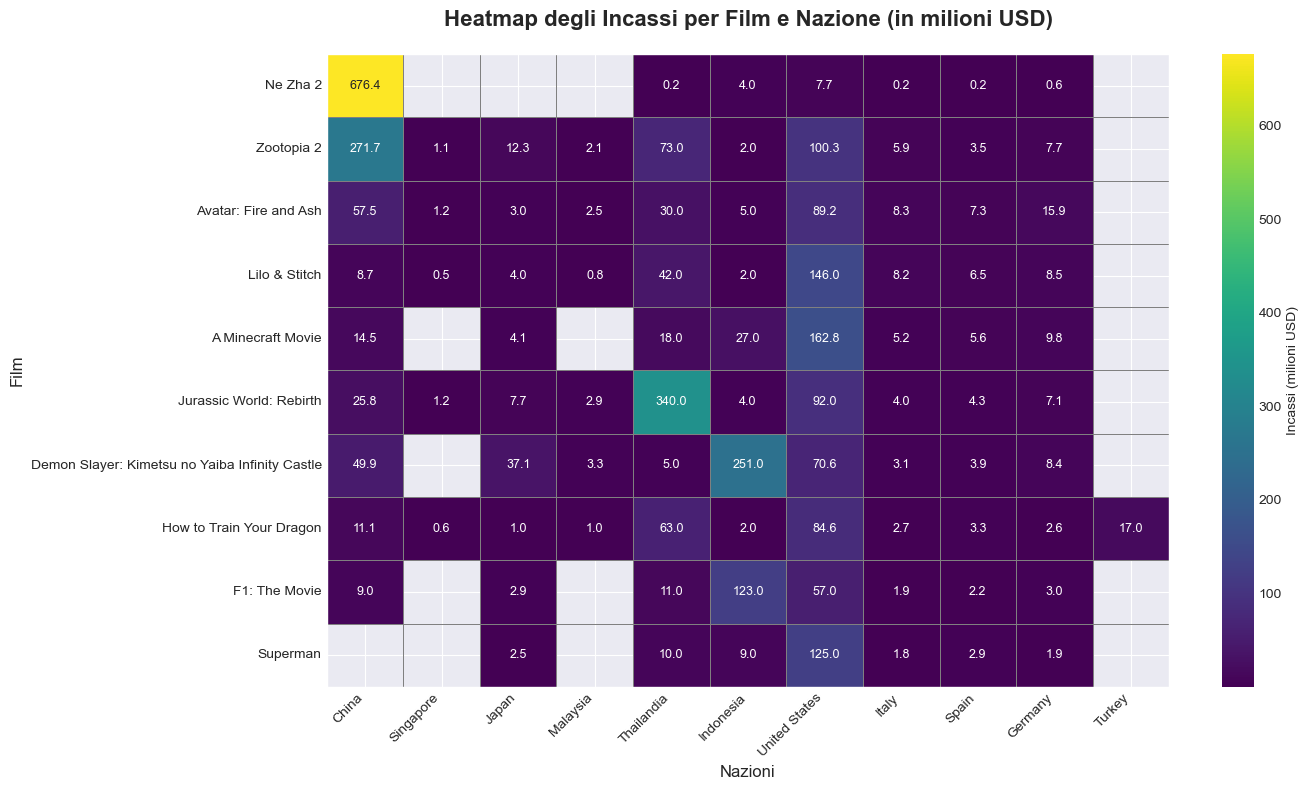


STATISTICHE DI BASE

TOTALE INCASSI PER NAZIONE:
China: $1,124,585,841
United States: $935,164,234
Thailandia: $592,211,000
Indonesia: $429,000,000
Japan: $74,700,324
Germany: $65,336,528
Italy: $41,257,617
Spain: $39,873,482
Turkey: $17,000,000
Malaysia: $12,494,834
Singapore: $4,681,135

MEDIA INCASSI PER FILM PER NAZIONE:
China: $124,953,982
Singapore: $936,227
Japan: $8,300,036
Malaysia: $2,082,472
Thailandia: $59,221,100
Indonesia: $42,900,000
United States: $93,516,423
Italy: $4,125,762
Spain: $3,987,348
Germany: $6,533,653
Turkey: $17,000,000

ISTOGRAMMI - STATI UNITI E CINA


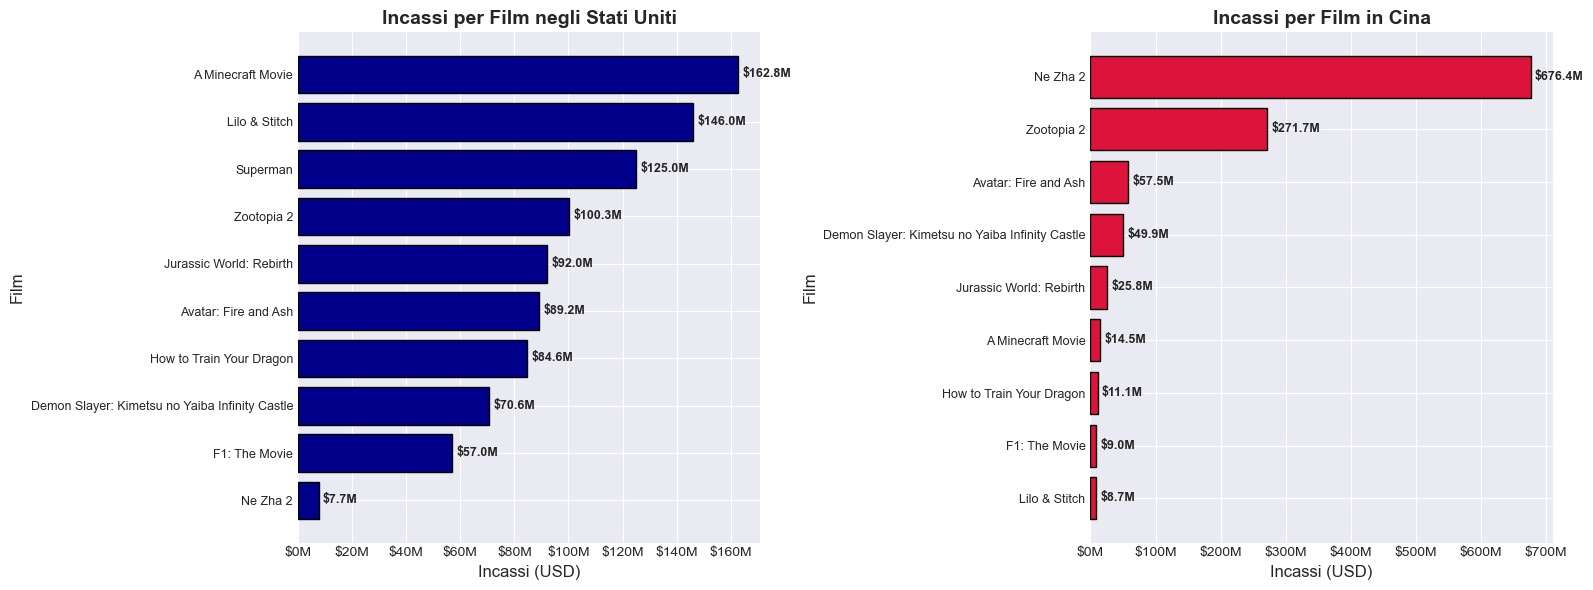


CONFRONTO CINA vs STATI UNITI

TOP 5 FILM IN CINA:
Ne Zha 2: $676,400,000
Zootopia 2: $271,724,258
Avatar: Fire and Ash: $57,527,285
Demon Slayer: Kimetsu no Yaiba Infinity Castle: $49,900,000
Jurassic World: Rebirth: $25,780,714

TOP 5 FILM NEGLI STATI UNITI:
A Minecraft Movie: $162,753,003
Lilo & Stitch: $146,016,175
Superman: $125,021,735
Zootopia 2: $100,262,540
Jurassic World: Rebirth: $92,016,065


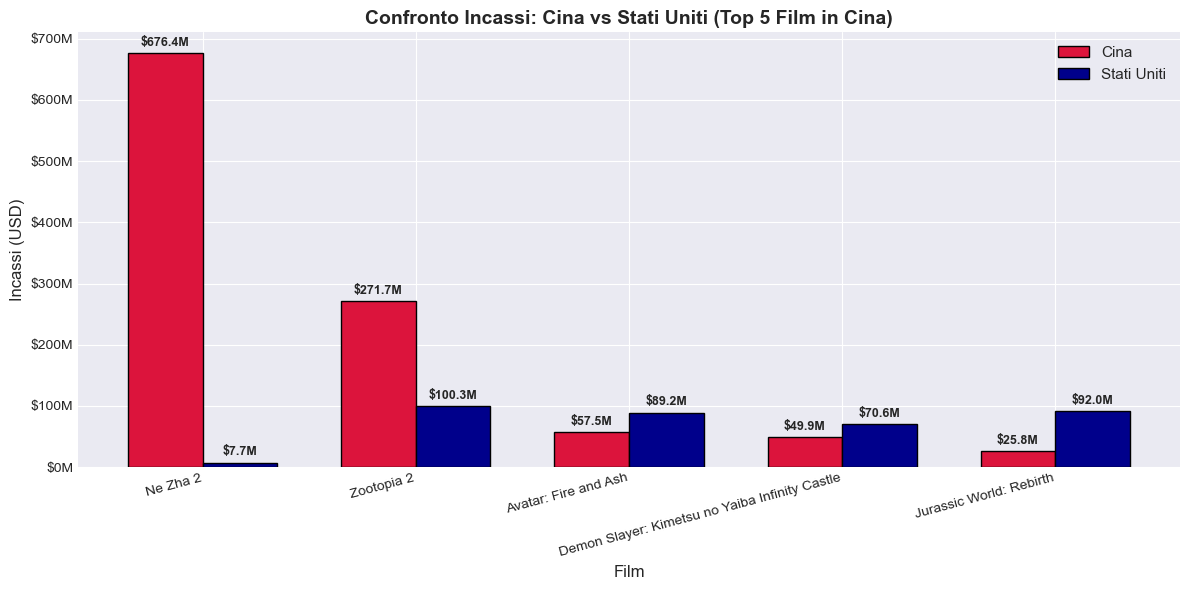


INFORMAZIONI SUL DATASET
Numero totale di film: 10
Numero di paesi/regioni: 11
Paesi/regioni inclusi: China, Singapore, Japan, Malaysia, Thailandia, Indonesia, United States, Italy, Spain, Germany, Turkey

RIEPILOGO NUMERICO (valori in milioni USD)


,Nome film,China,Singapore,Japan,Malaysia,Thailandia,Indonesia,United States,Italy,Spain,Germany,Turkey
0,Ne Zha 2,676.40,NaN,NaN,NaN,0.21,4.0,7.69,0.21,0.22,0.57,NaN
1,Zootopia 2,271.72,1.13,12.28,2.08,73.00,2.0,100.26,5.87,3.52,7.75,NaN
2,Avatar: Fire and Ash,57.53,1.24,3.05,2.49,30.00,5.0,89.16,8.31,7.31,15.93,NaN
3,Lilo & Stitch,8.66,0.46,4.01,0.78,42.00,2.0,146.02,8.16,6.51,8.51,NaN
4,A Minecraft Movie,14.50,NaN,4.14,NaN,18.00,27.0,162.75,5.21,5.61,9.75,NaN



HEATMAP CON LOG SCALE (per evidenziare differenze)


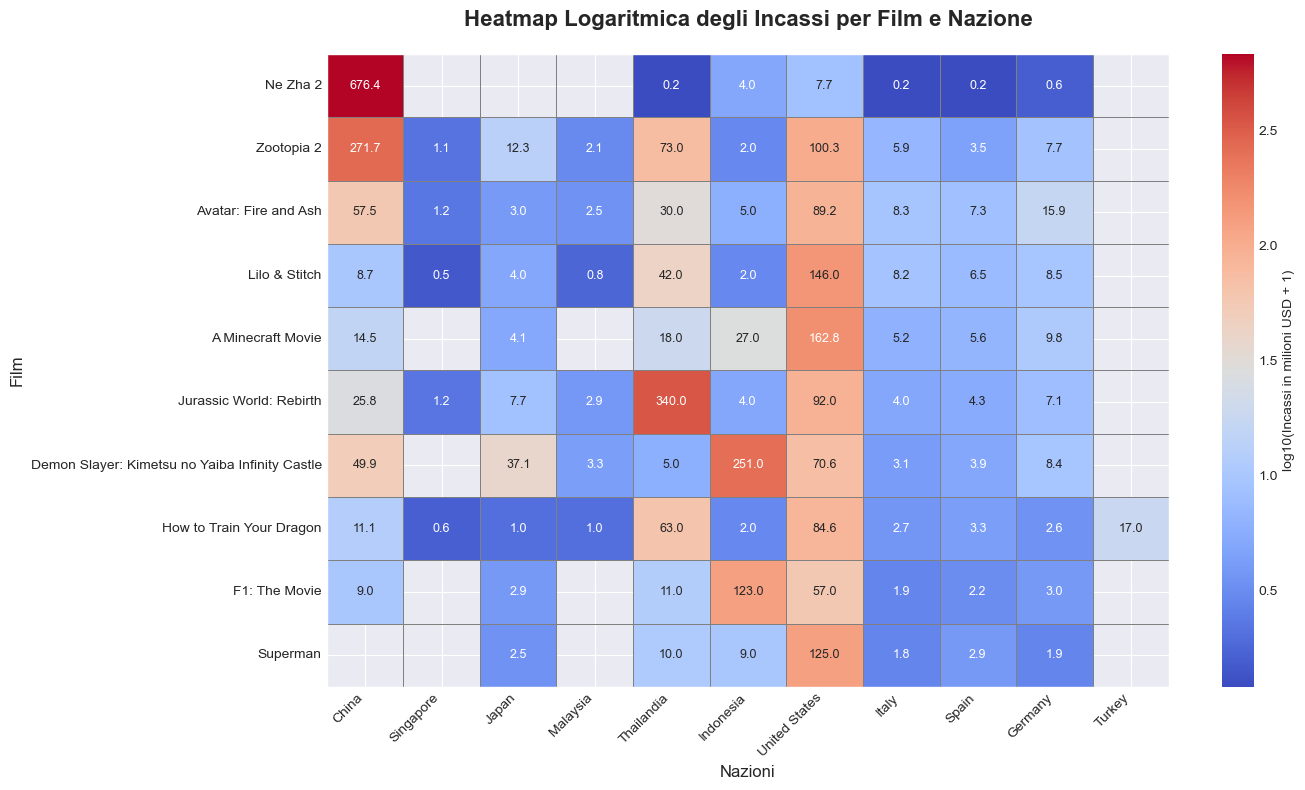

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Configurazione grafica
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Caricamento dei dati dal CSV
df_csv = pd.read_csv('opening - Foglio1 (1).csv')

# Pulisci i dati dal CSV: rimuovi i simboli $ e le virgole, converti in numerici
def clean_currency(value):
    if isinstance(value, str) and value != '-':
        # Rimuovi $, virgole e spazi
        cleaned = value.replace('$', '').replace(',', '').replace(' ', '')
        try:
            return float(cleaned)
        except:
            return np.nan
    elif value == '-' or pd.isna(value):
        return np.nan
    return value

# Applica la pulizia a tutte le colonne tranne la prima
for col in df_csv.columns[1:]:
    df_csv[col] = df_csv[col].apply(clean_currency)

# Rinomina America per chiarezza
df_csv = df_csv.rename(columns={'America': 'United States'})

# Dati dalla "tabella" dell'immagine
html_data = """ChinaIndonesiaJapanMalaysiaThailandItalySpainTurkeyNe Zha 2$2210M$4M$7M$23M$211K$221K$968KZootopia 2$631M$2M$6M$140M$73M$27M$49MAvatar: Fire and Ash$163M$5M$16M$10M$30M$36M$38MLilo & Stitch$25M$2M$23M$3M$42M$28M$28MA Minecraft Movie$29M$27M$12M$14M$18M$40MJurassic World: Rebirth$79M$4M$33M$8M$340M$13M$22MDemon Slayer: Kimetsu no Yaiba Infinity Castle$50M$251M$7M$135M$5M$9M$15MHow to Train Your Dragon$40M$2M$3M$4M$63M$11M$17M$17MF1: The Movie$59M$123M$130M$8M$11M$17MSuperman$9M$9M$134M$7M$10M$7M"""

# Elenco dei film dal primo dataset per riferimento
films_from_csv = df_csv['Nome film'].tolist()

# Paesi che appaiono nell'intestazione
countries_from_html = ['China', 'Indonesia', 'Japan', 'Malaysia', 'Thailand', 'Italy', 'Spain', 'Turkey']

# Funzione per convertire valori come "2210M", "4M", "211K" in numeri
def convert_html_value(val_str):
    if not val_str or pd.isna(val_str):
        return np.nan
    
    val_str = str(val_str).strip()
    if val_str.endswith('M'):
        return float(val_str.replace('M', '')) * 1_000_000
    elif val_str.endswith('K'):
        return float(val_str.replace('K', '')) * 1_000
    else:
        try:
            return float(val_str)
        except:
            return np.nan

# Creiamo manualmente il DataFrame dai dati HTML
html_rows = []

# Lista dei film in ordine di apparizione
films_in_order = [
    'Ne Zha 2',
    'Zootopia 2', 
    'Avatar: Fire and Ash',
    'Lilo & Stitch',
    'A Minecraft Movie',
    'Jurassic World: Rebirth',
    'Demon Slayer: Kimetsu no Yaiba Infinity Castle',
    'How to Train Your Dragon',
    'F1: The Movie',
    'Superman'
]

# Per ogni film, troviamo la sua posizione e estraiamo i dati
for i, film in enumerate(films_in_order):
    if film in html_data:
        # Trova l'indice di inizio di questo film
        start_idx = html_data.find(film)
        film_text = html_data[start_idx:]
        
        # Trova l'indice del prossimo film (se esiste)
        next_film = None
        for next_f in films_in_order[i+1:]:
            if next_f in film_text[len(film):]:
                next_film = next_f
                break
        
        if next_film:
            # Estrai il testo fino al prossimo film
            end_idx = film_text.find(next_film)
            film_data_text = film_text[:end_idx]
        else:
            # Ultimo film, prendi tutto il resto
            film_data_text = film_text
        
        # Rimuovi il nome del film dal testo
        film_data_text = film_data_text.replace(film, '').strip()
        
        # Estrai tutti i valori con $ (formato $numeroM o $numeroK)
        values = re.findall(r'\$(\d+\.?\d*[MK]?)', film_data_text)
        
        # Se non abbiamo abbastanza valori, aggiungiamo NaN
        while len(values) < len(countries_from_html):
            values.append(np.nan)
        
        # Prendi solo i primi 8 valori (per 8 paesi)
        values = values[:len(countries_from_html)]
        
        html_rows.append([film] + values)

# Crea DataFrame dai dati HTML
df_html = pd.DataFrame(html_rows, columns=['Nome film'] + countries_from_html)

# Applica la conversione a tutte le colonne numeriche
for col in countries_from_html:
    df_html[col] = df_html[col].apply(convert_html_value)

# Ora uniamo i due DataFrame
df_combined = df_csv.copy()

# Aggiungi le colonne mancanti dal DataFrame HTML
for country in countries_from_html:
    if country not in df_combined.columns:
        # Per ogni film, cerca il valore nel df_html
        values = []
        for film in df_combined['Nome film']:
            film_data = df_html[df_html['Nome film'] == film]
            if not film_data.empty:
                values.append(film_data[country].iloc[0])
            else:
                values.append(np.nan)
        
        if any(not pd.isna(v) for v in values):
            df_combined[country] = values

# Rinomina Thailand in Thailandia per coerenza
if 'Thailand' in df_combined.columns:
    df_combined = df_combined.rename(columns={'Thailand': 'Thailandia'})

# Seleziona e ordina le colonne
countries = ['China', 'Singapore', 'Japan', 'Malaysia', 'Thailandia', 'Indonesia', 
             'United States', 'Italy', 'Spain', 'Germany', 'Turkey']

# Mantieni solo le colonne che esistono
available_countries = []
for country in countries:
    if country in df_combined.columns:
        available_countries.append(country)

df_final = df_combined[['Nome film'] + available_countries]

# HEATMAP invece della tabella testuale
print("=" * 100)
print("HEATMAP - INCASSI PER FILM E NAZIONE")
print("=" * 100)

# Prepara i dati per la heatmap
heatmap_data = df_final.set_index('Nome film')[available_countries]

# Converti in milioni per una migliore visualizzazione
heatmap_data_millions = heatmap_data / 1_000_000

# Crea la heatmap
plt.figure(figsize=(14, 8))

# Usa una colormap viridis per i valori più alti
heatmap = sns.heatmap(heatmap_data_millions, 
                      annot=True, 
                      fmt=".1f", 
                      cmap="viridis",
                      linewidths=0.5,
                      linecolor='gray',
                      cbar_kws={'label': 'Incassi (milioni USD)'},
                      annot_kws={"size": 9})

plt.title('Heatmap degli Incassi per Film e Nazione (in milioni USD)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nazioni', fontsize=12)
plt.ylabel('Film', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Aggiungi un bordo alla heatmap
for _, spine in heatmap.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(1)

plt.tight_layout()
plt.show()

# Statistiche di base
print("\n" + "=" * 100)
print("STATISTICHE DI BASE")
print("=" * 100)

# Calcola il totale per paese
totals = df_final[available_countries].sum().sort_values(ascending=False)
print("\nTOTALE INCASSI PER NAZIONE:")
for country, total in totals.items():
    print(f"{country}: ${total:,.0f}")

# Calcola la media per paese
print("\nMEDIA INCASSI PER FILM PER NAZIONE:")
for country in available_countries:
    avg = df_final[country].mean()
    print(f"{country}: ${avg:,.0f}")

# ISTOGRAMMI
print("\n" + "=" * 100)
print("ISTOGRAMMI - STATI UNITI E CINA")
print("=" * 100)

# 1. Istogramma per gli Stati Uniti
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Istogramma Stati Uniti
if 'United States' in df_final.columns:
    us_data = df_final[['Nome film', 'United States']].dropna().sort_values('United States', ascending=False)
    axes[0].barh(us_data['Nome film'], us_data['United States'], color='darkblue', edgecolor='black')
    axes[0].set_xlabel('Incassi (USD)', fontsize=12)
    axes[0].set_ylabel('Film', fontsize=12)
    axes[0].set_title('Incassi per Film negli Stati Uniti', fontsize=14, fontweight='bold')
    axes[0].invert_yaxis()  # Film con incassi più alti in alto
    axes[0].tick_params(axis='x', labelsize=10)
    axes[0].tick_params(axis='y', labelsize=9)
    
    # Formatta l'asse x in milioni
    def millions_formatter(x, pos):
        return f'${x/1_000_000:.0f}M'
    axes[0].xaxis.set_major_formatter(plt.FuncFormatter(millions_formatter))
    
    # Aggiungi i valori sulle barre
    if not us_data.empty:
        for i, v in enumerate(us_data['United States']):
            if v >= 1_000_000:
                label = f'${v/1_000_000:.1f}M'
            else:
                label = f'${v:,.0f}'
            axes[0].text(v + max(us_data['United States']) * 0.01, i, label, 
                        va='center', fontsize=9, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'Dati Stati Uniti non disponibili', 
                ha='center', va='center', fontsize=14)
    axes[0].set_title('Incassi per Film negli Stati Uniti', fontsize=14, fontweight='bold')

# 2. Istogramma per la Cina
if 'China' in df_final.columns:
    china_data = df_final[['Nome film', 'China']].dropna().sort_values('China', ascending=False)
    axes[1].barh(china_data['Nome film'], china_data['China'], color='crimson', edgecolor='black')
    axes[1].set_xlabel('Incassi (USD)', fontsize=12)
    axes[1].set_ylabel('Film', fontsize=12)
    axes[1].set_title('Incassi per Film in Cina', fontsize=14, fontweight='bold')
    axes[1].invert_yaxis()  # Film con incassi più alti in alto
    axes[1].tick_params(axis='x', labelsize=10)
    axes[1].tick_params(axis='y', labelsize=9)
    
    # Formatta l'asse x in milioni
    axes[1].xaxis.set_major_formatter(plt.FuncFormatter(millions_formatter))
    
    # Aggiungi i valori sulle barre
    if not china_data.empty:
        for i, v in enumerate(china_data['China']):
            if v >= 1_000_000:
                label = f'${v/1_000_000:.1f}M'
            else:
                label = f'${v:,.0f}'
            axes[1].text(v + max(china_data['China']) * 0.01, i, label, 
                        va='center', fontsize=9, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Dati Cina non disponibili', 
                ha='center', va='center', fontsize=14)
    axes[1].set_title('Incassi per Film in Cina', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Confronto diretto Cina vs Stati Uniti (se disponibili)
if 'China' in df_final.columns and 'United States' in df_final.columns:
    print("\n" + "=" * 100)
    print("CONFRONTO CINA vs STATI UNITI")
    print("=" * 100)
    
    top_china = df_final[['Nome film', 'China']].dropna().nlargest(5, 'China')
    top_us = df_final[['Nome film', 'United States']].dropna().nlargest(5, 'United States')
    
    print("\nTOP 5 FILM IN CINA:")
    for idx, row in top_china.iterrows():
        print(f"{row['Nome film']}: ${row['China']:,.0f}")
    
    print("\nTOP 5 FILM NEGLI STATI UNITI:")
    for idx, row in top_us.iterrows():
        print(f"{row['Nome film']}: ${row['United States']:,.0f}")
    
    # Grafico a barre per confronto top 5 film in Cina
    fig2, ax2 = plt.subplots(figsize=(12, 6))
    
    # Prendi i film che sono in entrambe le liste o almeno nei top cinesi
    china_films = top_china['Nome film'].tolist()
    china_values = top_china['China'].tolist()
    us_values = []
    
    # Trova i valori corrispondenti per gli Stati Uniti
    for film in china_films:
        us_value = df_final.loc[df_final['Nome film'] == film, 'United States']
        if not us_value.empty and not pd.isna(us_value.iloc[0]):
            us_values.append(us_value.iloc[0])
        else:
            us_values.append(0)
    
    # Crea le barre solo se abbiamo dati
    if china_values and us_values:
        x = np.arange(len(china_films))
        width = 0.35
        
        bars1 = ax2.bar(x - width/2, china_values, width, label='Cina', color='crimson', edgecolor='black')
        bars2 = ax2.bar(x + width/2, us_values, width, label='Stati Uniti', color='darkblue', edgecolor='black')
        
        # Configura il grafico
        ax2.set_xlabel('Film', fontsize=12)
        ax2.set_ylabel('Incassi (USD)', fontsize=12)
        ax2.set_title('Confronto Incassi: Cina vs Stati Uniti (Top 5 Film in Cina)', fontsize=14, fontweight='bold')
        ax2.set_xticks(x)
        ax2.set_xticklabels(china_films, rotation=15, ha='right', fontsize=10)
        ax2.legend(fontsize=11)
        ax2.tick_params(axis='y', labelsize=10)
        
        # Formatta l'asse y in milioni
        ax2.yaxis.set_major_formatter(plt.FuncFormatter(millions_formatter))
        
        # Aggiungi le etichette sui valori
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                if height > 0:
                    if height >= 1_000_000:
                        label = f'${height/1_000_000:.1f}M'
                    else:
                        label = f'${height:,.0f}'
                    ax2.text(bar.get_x() + bar.get_width()/2, height + max(china_values)*0.01,
                            label, ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Informazioni sul dataset
print("\n" + "=" * 100)
print("INFORMAZIONI SUL DATASET")
print("=" * 100)
print(f"Numero totale di film: {len(df_final)}")
print(f"Numero di paesi/regioni: {len(available_countries)}")
print(f"Paesi/regioni inclusi: {', '.join(available_countries)}")

# Mostra anche una tabella numerica di riepilogo (in forma testuale per completezza)
print("\n" + "=" * 100)
print("RIEPILOGO NUMERICO (valori in milioni USD)")
print("=" * 100)

df_summary = df_final.copy()
for col in available_countries:
    df_summary[col] = df_summary[col] / 1_000_000

# Arrotonda a 2 decimali
df_summary = df_summary.round(2)

# Visualizza solo le prime righe per non sovraccaricare l'output
display(df_summary.head())

# Heatmap alternativa con log scale per visualizzare meglio le differenze
print("\n" + "=" * 100)
print("HEATMAP CON LOG SCALE (per evidenziare differenze)")
print("=" * 100)

plt.figure(figsize=(14, 8))

# Applica log10 ai dati per la heatmap (aggiungi 1 per evitare log(0))
heatmap_data_log = np.log10(heatmap_data_millions + 1)

heatmap_log = sns.heatmap(heatmap_data_log, 
                         annot=heatmap_data_millions,  # Mostra i valori originali come annotazioni
                         fmt=".1f", 
                         cmap="coolwarm",
                         linewidths=0.5,
                         linecolor='gray',
                         cbar_kws={'label': 'log10(Incassi in milioni USD + 1)'},
                         annot_kws={"size": 9})

plt.title('Heatmap Logaritmica degli Incassi per Film e Nazione', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nazioni', fontsize=12)
plt.ylabel('Film', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Aggiungi un bordo alla heatmap
for _, spine in heatmap_log.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(1)

plt.tight_layout()
plt.show()